# Clasp Weighted-Sequence: brute-force RF schedule analytics

This notebook compares all 50 three-phase RF schedules, the five
deterministic fixed-depth controls from `03_fixed_deterministic`
requested for the comparison, and the five matched PCA=4
fixed-depth controls from `04_fixed_deterministic_pca4`.

Every reported performance is the incumbent configuration's mean
PAR10 over **all training instances**, evaluated with surrogate
quantile seed 0. Lower PAR10 is better. Rankings therefore do not
use SMAC's partial-instance incumbent cost.

The three schedule phases cover trials 0–499, 500–1,999, and
2,000–4,999. All schedules use 100 trees, minimum leaf size 1,
PCA=4, and deterministic target values.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

HERE = Path.cwd().resolve()
if not (HERE / "schedule_catalog.json").is_file():
    HERE = (
        Path.cwd()
        / "experiments/aclib"
        / "clasp_weighted-sequence_surrogate"
        / "05_bruteforce_rf_schedules"
    ).resolve()
ACLIB_ROOT = HERE.parents[1]
if str(ACLIB_ROOT) not in sys.path:
    sys.path.insert(0, str(ACLIB_ROOT))

from rf_schedule_notebook_analytics import (
    build_notebook_data,
    findings_markdown,
    plot_checkpoint_trajectories,
    plot_early_vs_final,
    plot_overall_ranking,
    plot_phase_effects,
    plot_rank_stability,
    plot_runtime_performance,
    plot_top_five_by_seed,
    top_five_by_seed,
    top_five_overall,
    top_policy_definitions,
)

BENCHMARK_KEY = "clasp_weighted"
DISPLAY_NAME = "Clasp Weighted-Sequence"
plt.rcParams.update({"figure.dpi": 120, "axes.grid": False})
print("Experiment:", HERE)

Experiment: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/clasp_weighted-sequence_surrogate/05_bruteforce_rf_schedules


## Data loading and audit

The schedule checkpoint values were already independently
validated on all training instances. The first execution may
validate missing fixed-depth incumbents and cache those values in
the corresponding fixed experiment's `analytics_cache` directory.

The audit table confirms the number of distinct policies and
seed runs included in each policy class.

In [2]:
data = build_notebook_data(HERE, BENCHMARK_KEY)
audit = (
    data.policy_rows.groupby("policy_type")
    .agg(
        policies=("policy_id", "nunique"),
        policy_seed_rows=("policy_id", "size"),
        seeds=("smac_seed", "nunique"),
        minimum_final_trials=("par10_5000", "count"),
    )
    .reset_index()
)
display(audit)
assert data.policy_rows["policy_id"].nunique() == 60
assert len(data.policy_rows) == 180

,policy_type,policies,policy_seed_rows,seeds,minimum_final_trials
0,fixed depth (PCA=4),5,15,3,15
1,fixed depth (no PCA),5,15,3,15
2,three-phase schedule (PCA=4),50,150,3,150


## Top five policies for each SMAC seed

Each seed is ranked independently by final full-training PAR10 at
trial 5,000. This reveals whether one schedule wins consistently
or whether the preferred schedule depends strongly on SMAC's
optimization seed. Bars include schedules and both fixed-depth
control families.

,smac_seed,seed_rank,policy_id,policy_label,policy_type,par10_5000,par10_500,improvement_500_5000
0,0,1,schedule_33,Schedule 33,three-phase schedule (PCA=4),48.496876,53.667109,5.170233
1,0,1,schedule_45,Schedule 45,three-phase schedule (PCA=4),48.496876,53.667109,5.170233
2,0,3,schedule_24,Schedule 24,three-phase schedule (PCA=4),49.192031,53.420201,4.228170
3,0,4,fixed_p4_d15,Fixed d15 (PCA=4),fixed depth (PCA=4),50.322153,51.303992,0.981839
4,0,5,schedule_48,Schedule 48,three-phase schedule (PCA=4),50.411016,59.965296,9.554280
5,1,1,schedule_10,Schedule 10,three-phase schedule (PCA=4),48.976619,51.373359,2.396739
6,1,2,schedule_01,Schedule 01,three-phase schedule (PCA=4),49.839837,62.136204,12.296367
7,1,2,schedule_28,Schedule 28,three-phase schedule (PCA=4),49.839837,53.632725,3.792887
8,1,4,schedule_16,Schedule 16,three-phase schedule (PCA=4),50.292135,53.632725,3.340590
9,1,5,fixed_np_d20,Fixed d20 (no PCA),fixed depth (no PCA),50.548710,52.837242,2.288532


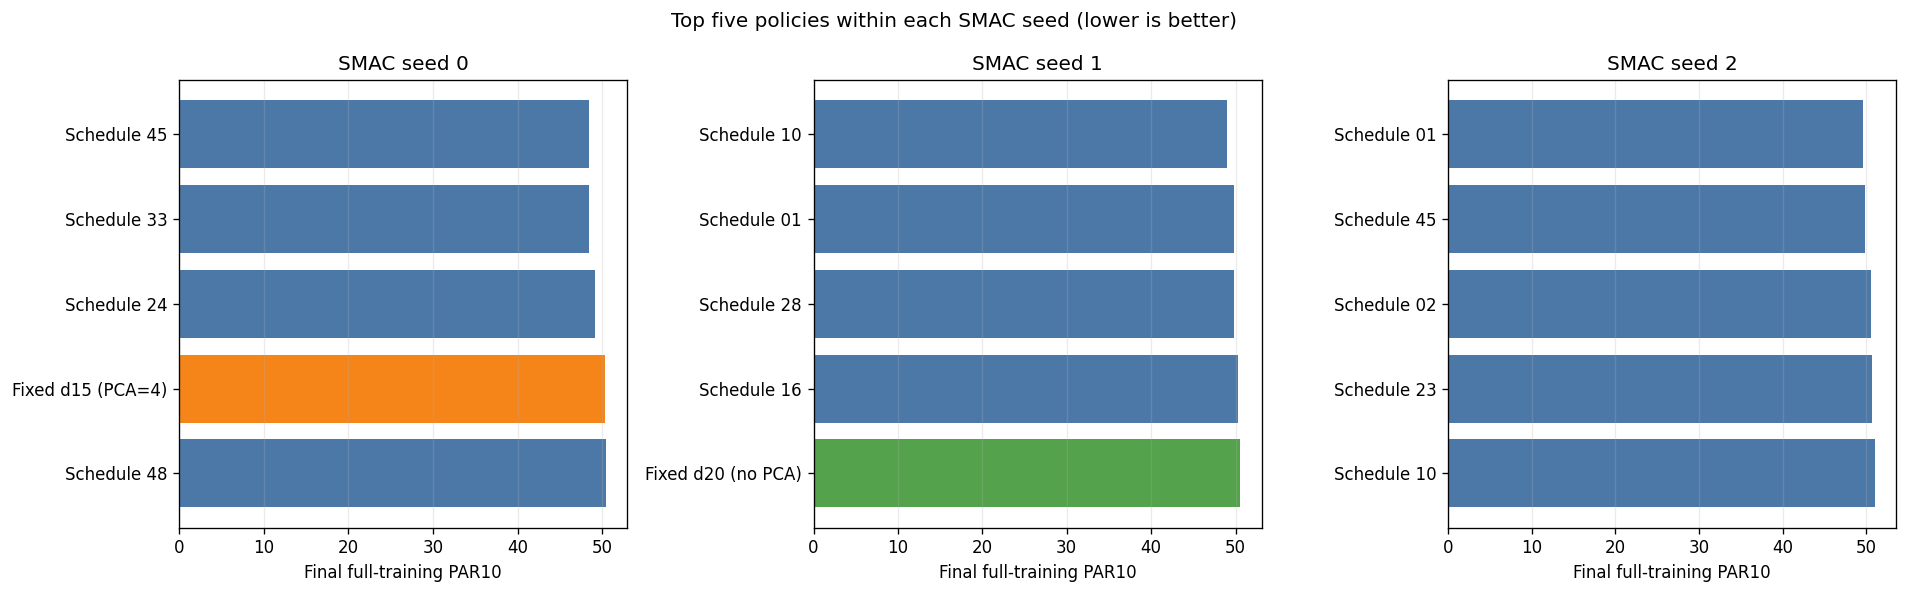

In [3]:
seed_top5 = top_five_by_seed(data)
display(seed_top5)
plot_top_five_by_seed(data)
plt.show()

## Top five policies across all SMAC seeds

The primary cross-seed ranking uses mean final full-training
PAR10. Standard deviation, worst-seed performance, mean seed rank,
and worst seed rank show how much confidence to place in the mean.
The plot displays the top 15 so near-ties and fixed baselines
remain visible.

,overall_rank,policy_id,policy_label,policy_type,final_mean,final_std,final_worst,mean_seed_rank,worst_seed_rank,improvement_500_5000_mean
0,1,schedule_45,Schedule 45,three-phase schedule (PCA=4),50.060764,1.697757,51.866461,7.333333,19,6.235279
1,2,schedule_24,Schedule 24,three-phase schedule (PCA=4),50.434776,1.076457,51.077324,6.000000,8,7.870984
2,3,schedule_01,Schedule 01,three-phase schedule (PCA=4),50.801379,1.811025,52.890375,11.333333,31,8.896995
3,4,schedule_10,Schedule 10,three-phase schedule (PCA=4),51.082803,2.142454,53.259773,14.000000,36,4.483543
4,5,schedule_04,Schedule 04,three-phase schedule (PCA=4),51.379338,0.827076,52.228055,12.666667,23,3.099236


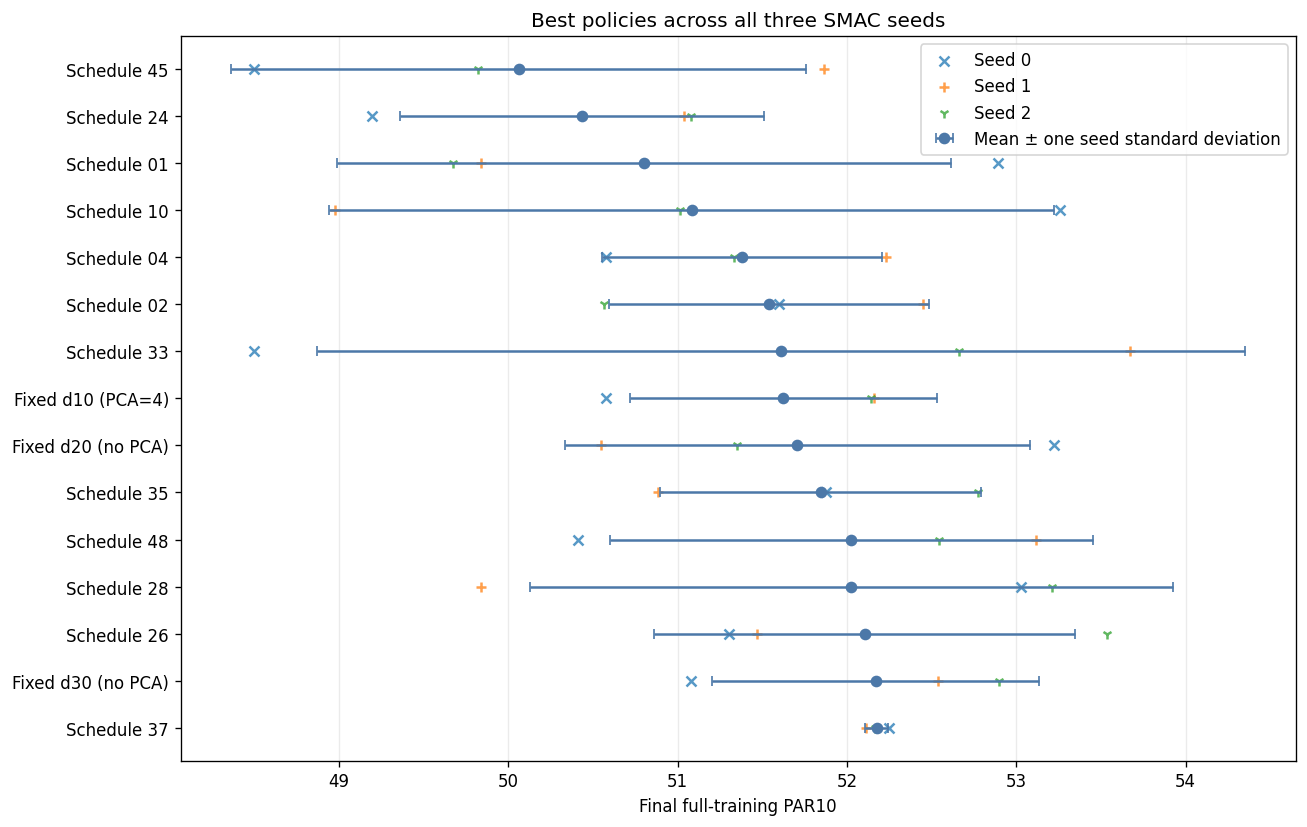

In [4]:
overall_top5 = top_five_overall(data)
display(overall_top5)
plot_overall_ranking(data, top_n=15)
plt.show()

## RF definitions of the leading policies

This table expands each leading policy into its depth,
minimum-split size, and feature ratio in the three phases. Fixed
controls repeat the same setting in every phase. It makes repeated
motifs among successful schedules directly visible.

In [5]:
definitions = top_policy_definitions(data, top_n=12)
display(definitions)

,overall_rank,policy_id,final_mean,final_std,policy_type,phase_0_depth,phase_0_min_samples_split,phase_0_feature_ratio,phase_1_depth,phase_1_min_samples_split,phase_1_feature_ratio,phase_2_depth,phase_2_min_samples_split,phase_2_feature_ratio
0,1,schedule_45,50.060764,1.697757,three-phase schedule (PCA=4),5,8,0.833333,5,8,0.833333,30,8,0.833333
1,2,schedule_24,50.434776,1.076457,three-phase schedule (PCA=4),10,2,0.500000,5,4,1.000000,15,4,1.000000
2,3,schedule_01,50.801379,1.811025,three-phase schedule (PCA=4),10,4,0.833333,10,4,0.833333,10,4,0.833333
3,4,schedule_10,51.082803,2.142454,three-phase schedule (PCA=4),15,4,0.300000,15,4,0.500000,15,4,1.000000
4,5,schedule_04,51.379338,0.827076,three-phase schedule (PCA=4),5,8,0.300000,15,4,0.500000,30,2,1.000000
5,6,schedule_02,51.538055,0.945383,three-phase schedule (PCA=4),15,4,0.500000,15,4,0.500000,15,4,0.500000
6,7,schedule_33,51.610040,2.743172,three-phase schedule (PCA=4),20,8,0.833333,15,8,0.833333,15,8,0.833333
7,8,fixed_p4_d10,51.625104,0.908811,fixed depth (PCA=4),10,1,0.833333,10,1,0.833333,10,1,0.833333
8,9,fixed_np_d20,51.707857,1.371949,fixed depth (no PCA),20,1,0.833333,20,1,0.833333,20,1,0.833333
9,10,schedule_35,51.844463,0.946257,three-phase schedule (PCA=4),5,2,0.300000,10,8,0.300000,5,8,0.300000


## Comparison with fixed-depth controls

For every schedule and seed, the table compares its final value
with the best fixed PCA=4 depth for that same seed. Negative deltas
favor the schedule. Wins count how many of the three seeds the
schedule beats. The no-PCA controls from `03_fixed_deterministic`
are also reported, but that delta combines policy and PCA effects.

In [6]:
fixed_summary = (
    data.aggregate_rankings[
        data.aggregate_rankings["policy_type"].str.startswith("fixed")
    ]
    .sort_values(["policy_type", "final_mean"])
    [
        [
            "policy_label",
            "policy_type",
            "overall_rank",
            "final_mean",
            "final_std",
            "final_worst",
            "mean_seed_rank",
        ]
    ]
)
display(fixed_summary)
display(data.baseline_comparison.head(15))

,policy_label,policy_type,overall_rank,final_mean,final_std,final_worst,mean_seed_rank
7,Fixed d10 (PCA=4),fixed depth (PCA=4),8,51.625104,0.908811,52.158805,13.666667
15,Fixed d15 (PCA=4),fixed depth (PCA=4),16,52.374896,2.843992,55.621171,23.000000
20,Fixed d20 (PCA=4),fixed depth (PCA=4),21,52.600234,1.395101,54.151897,25.333333
25,Fixed d30 (PCA=4),fixed depth (PCA=4),26,52.764306,0.336438,53.084597,27.000000
59,Fixed d5 (PCA=4),fixed depth (PCA=4),60,55.122726,0.354330,55.347772,54.333333
8,Fixed d20 (no PCA),fixed depth (no PCA),9,51.707857,1.371949,53.222592,16.666667
13,Fixed d30 (no PCA),fixed depth (no PCA),14,52.170809,0.965137,52.899844,20.666667
39,Fixed d15 (no PCA),fixed depth (no PCA),40,53.358786,1.139859,54.666111,35.000000
47,Fixed d10 (no PCA),fixed depth (no PCA),48,53.901736,1.092924,55.021028,42.333333
49,Fixed d5 (no PCA),fixed depth (no PCA),50,53.991520,0.850378,54.850616,46.666667


,policy_id,policy_label,mean_delta_to_best_fixed_pca4,wins_vs_best_fixed_pca4,mean_delta_to_best_fixed_no_pca,wins_vs_best_fixed_no_pca
0,schedule_24,Schedule 24,-0.549558,3,-0.557655,2
1,schedule_45,Schedule 45,-0.923570,2,-0.931667,2
2,schedule_01,Schedule 01,-0.182955,2,-0.191051,2
3,schedule_10,Schedule 10,0.098469,2,0.090373,2
4,schedule_02,Schedule 02,0.553721,1,0.545624,1
5,schedule_33,Schedule 33,0.625706,1,0.617609,1
6,schedule_35,Schedule 35,0.860129,1,0.852033,0
7,schedule_28,Schedule 28,1.042638,1,1.034542,1
8,schedule_23,Schedule 23,1.400934,1,1.392837,1
9,schedule_30,Schedule 30,1.424806,1,1.416709,0


## How the leading policies improve over time

Lines show mean incumbent PAR10 at trials 500, 2,000, and 5,000;
shaded regions span the minimum to maximum across the three SMAC
seeds. A curve that improves mainly after a switch indicates that
later-phase settings may be useful, while a flat curve suggests
most useful progress happened early.

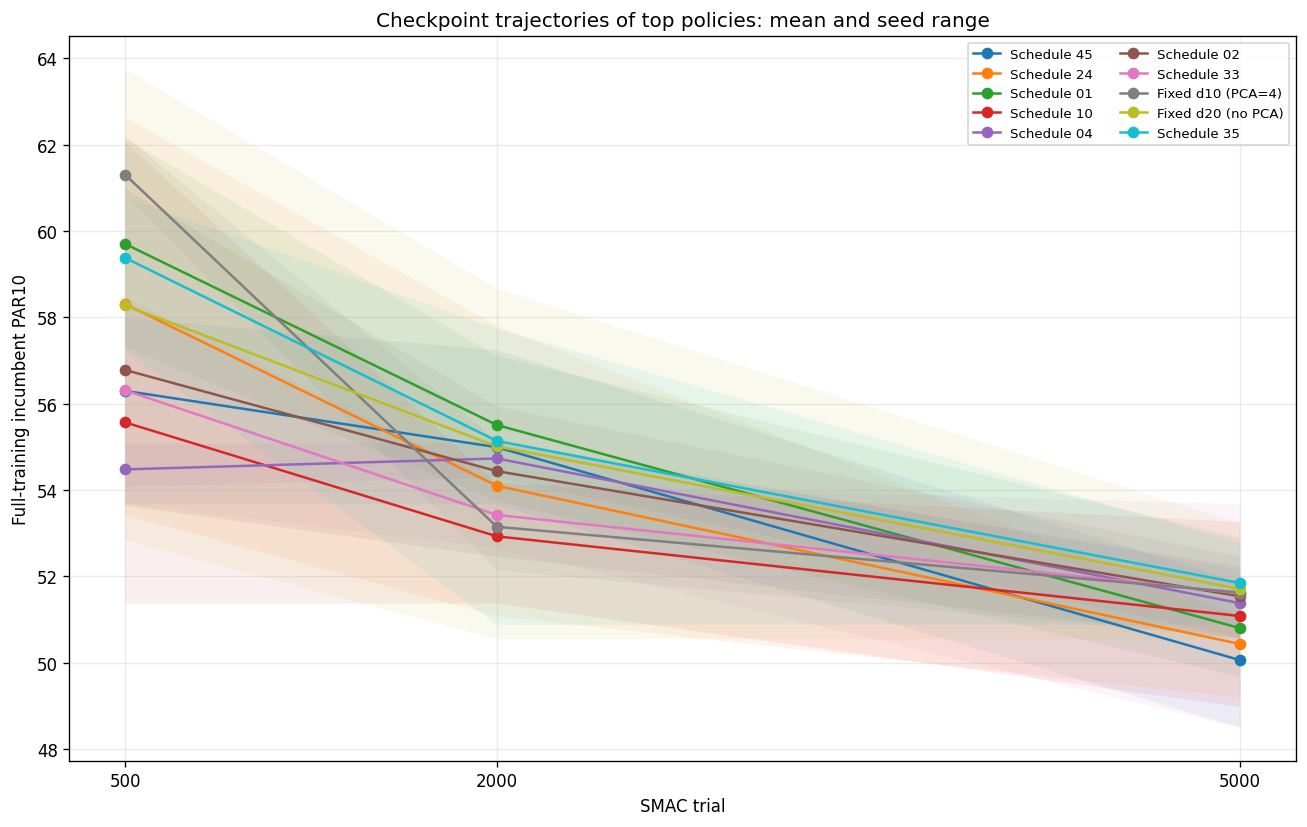

In [7]:
plot_checkpoint_trajectories(data, top_n=10)
plt.show()

## Cross-seed rank stability

The heatmap gives the rank of each overall leading policy within
every seed. Uniformly low ranks indicate a robust policy; a mix of
excellent and poor ranks warns that a good mean is driven by one
favorable seed.

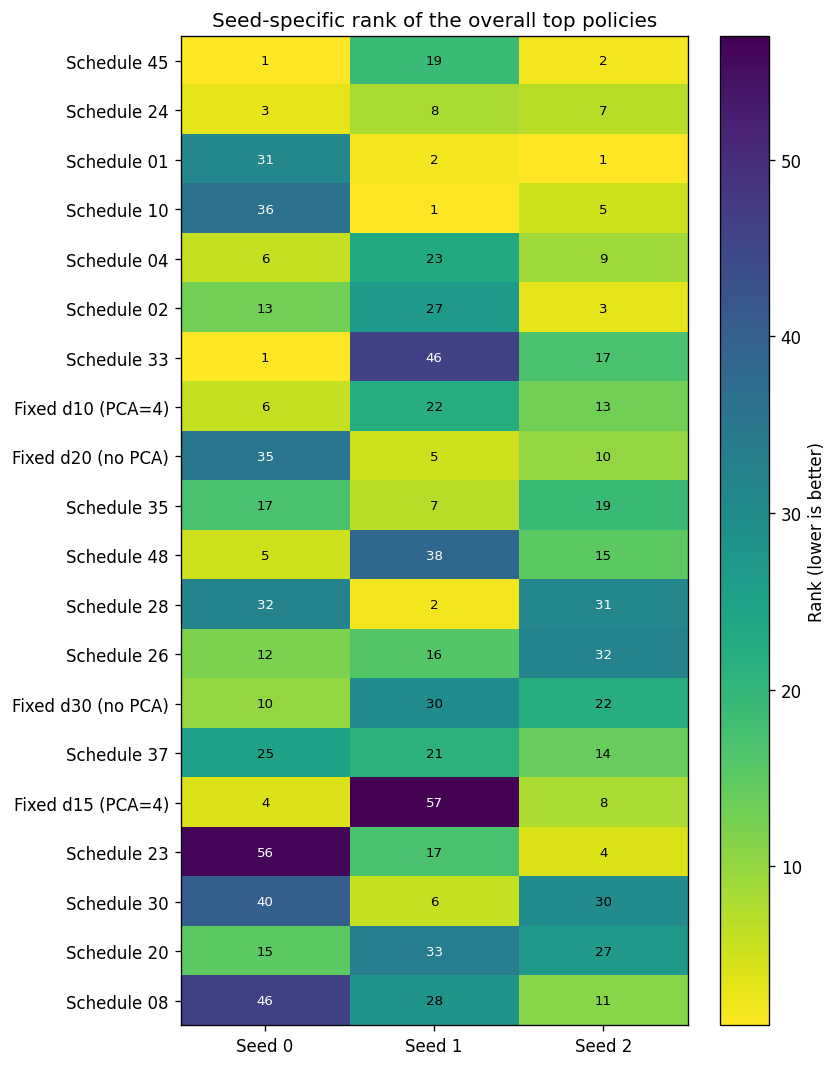

In [8]:
plot_rank_stability(data, top_n=20)
plt.show()

## Early performance versus final performance

This scatter plot tests whether success by trial 500 predicts the
final result. Points below the general trend are late improvers;
points that start well but finish poorly may use unsuitable
settings after a checkpoint.

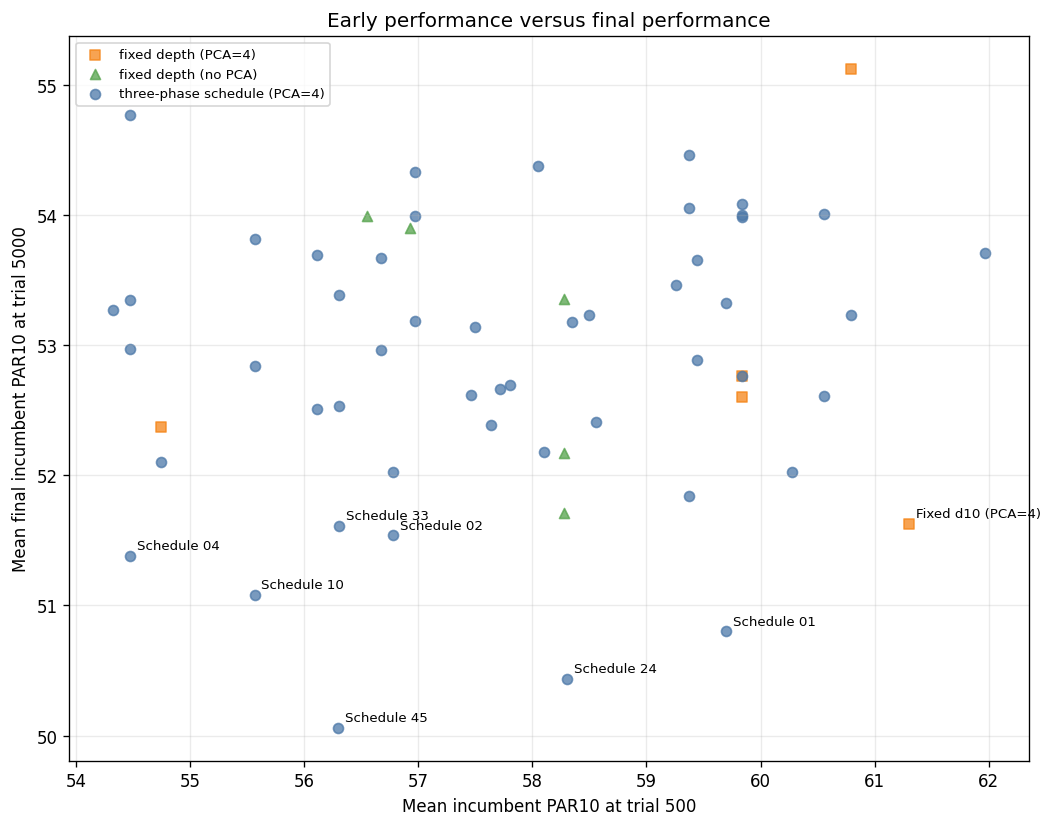

In [9]:
plot_early_vs_final(data)
plt.show()

## Marginal effects of phase settings

For phase 0, bars show PAR10 at trial 500 and lower is better. For
phases 1 and 2, bars show improvement during that phase and higher
is better. Error bars are standard deviations over all
schedule-seed runs carrying the setting.

These are descriptive associations, not isolated causal effects:
the 50 schedules are diverse rather than a complete factorial
design, so settings can be correlated across phases.

,phase,factor,value,metric,direction,runs,schedules,mean,median,std,final_mean
0,0,depth,5.000000,par10_500,lower is better,36,12,56.861244,56.927179,2.871036,52.757951
2,0,depth,15.000000,par10_500,lower is better,33,11,56.867824,56.583067,3.452581,52.958602
3,0,depth,20.000000,par10_500,lower is better,27,9,57.426754,57.621948,3.186201,52.850151
1,0,depth,10.000000,par10_500,lower is better,24,8,58.767748,58.506507,3.459112,52.459097
4,0,depth,30.000000,par10_500,lower is better,30,10,59.120487,59.909549,3.274000,53.431923
8,0,feature_ratio,0.300000,par10_500,lower is better,39,13,56.458214,55.075542,3.594376,53.052154
9,0,feature_ratio,0.500000,par10_500,lower is better,30,10,57.510148,58.277345,2.893317,52.501900
10,0,feature_ratio,0.833333,par10_500,lower is better,42,14,57.772876,57.273324,2.576186,52.704519
11,0,feature_ratio,1.000000,par10_500,lower is better,39,13,59.091546,59.324037,3.682353,53.286395
6,0,min_samples_split,4.000000,par10_500,lower is better,54,18,57.150674,56.690532,3.462311,52.897763


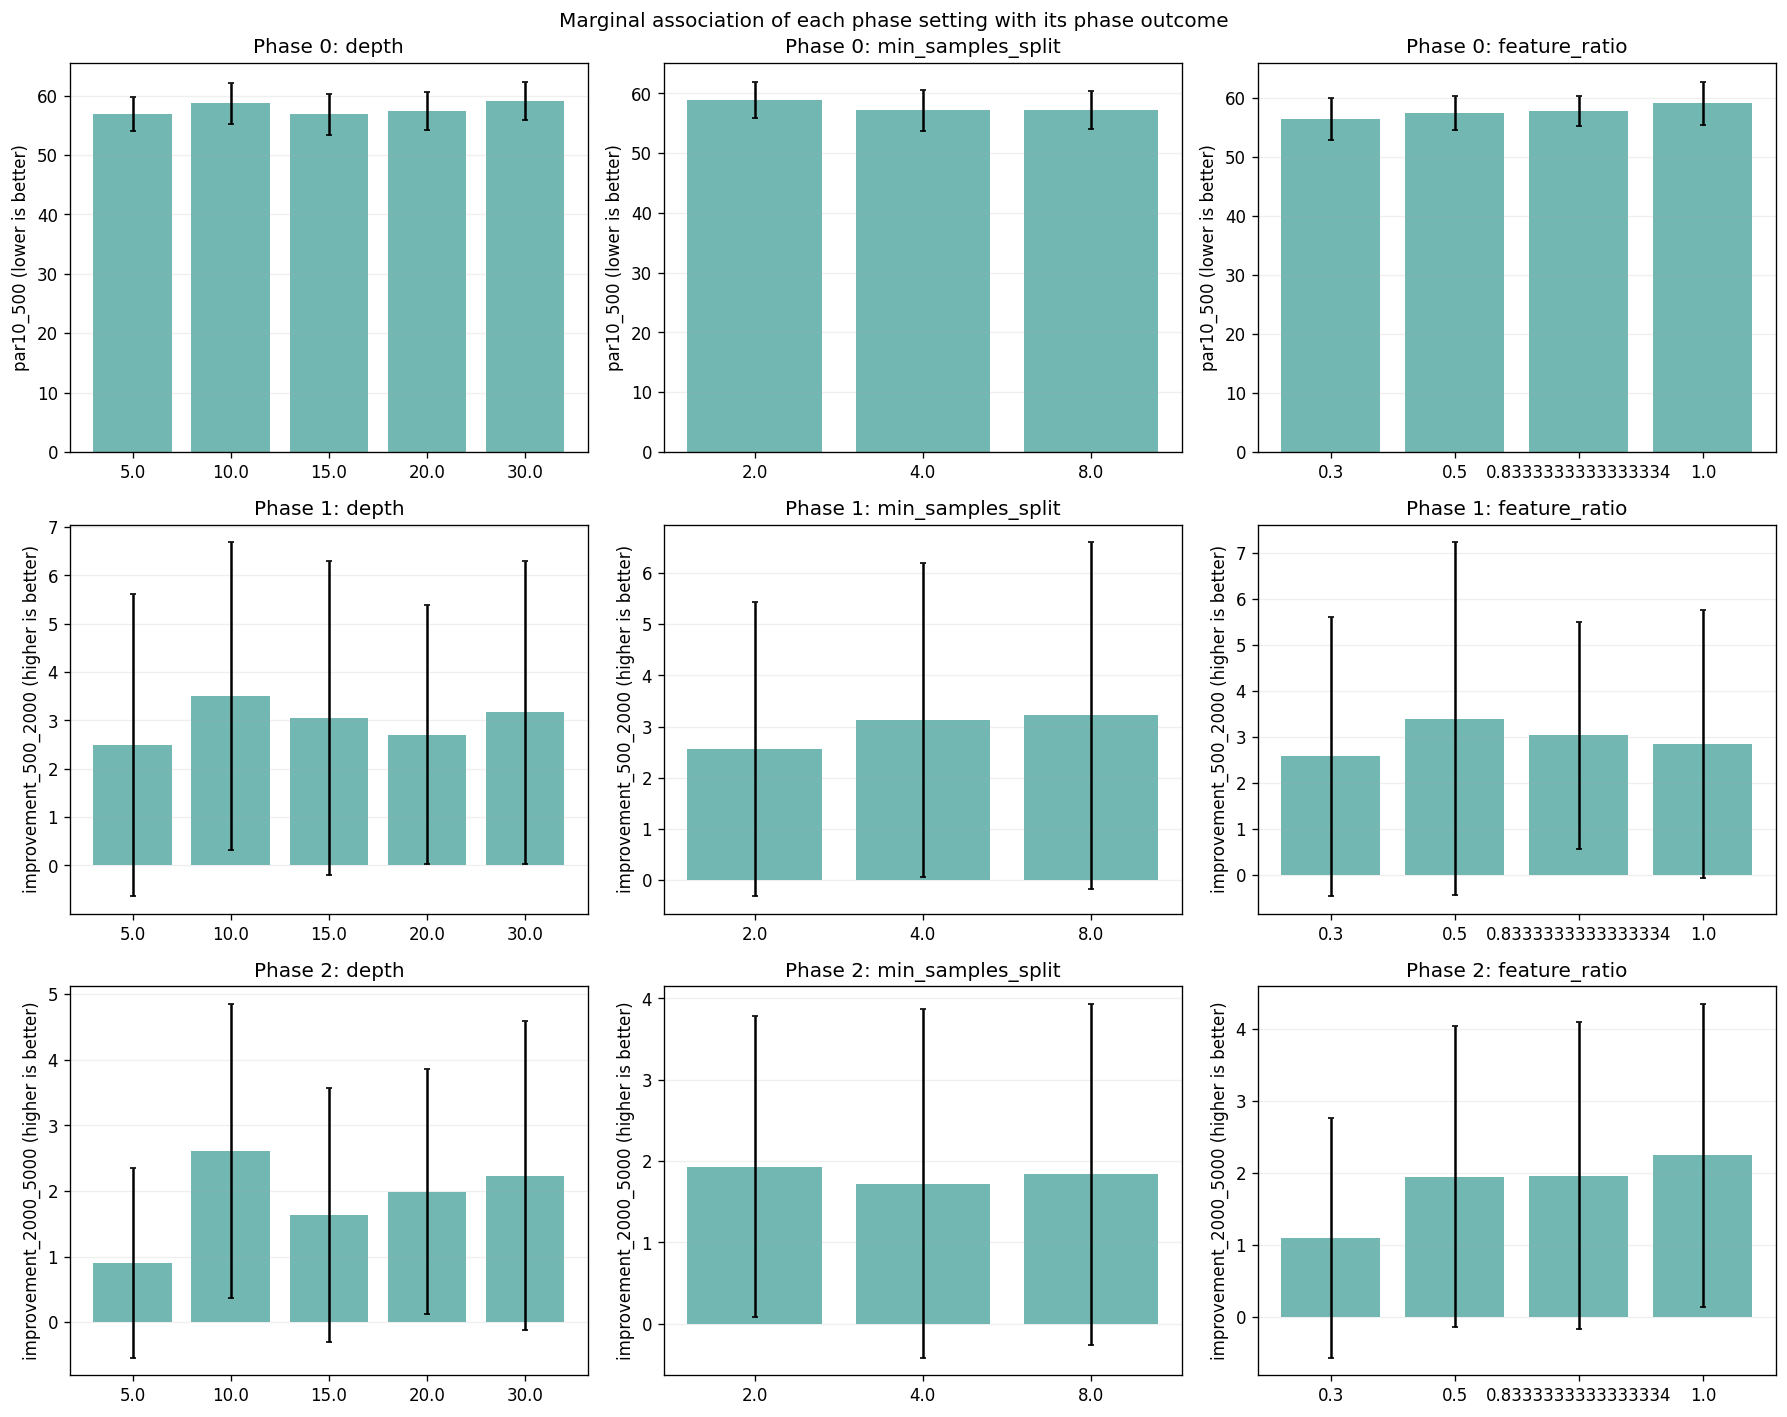

In [10]:
phase_table = data.phase_effects.sort_values(
    ["phase", "factor", "mean"],
    ascending=[True, True, True],
)
display(phase_table)
plot_phase_effects(data)
plt.show()

## Runtime–performance trade-off

The plot shows whether better policies systematically require more
wall time. Runtime is averaged across seeds. Cluster placement
also affects wall time, so this is useful for screening expensive
settings but should not be interpreted as a pure RF-cost
measurement.

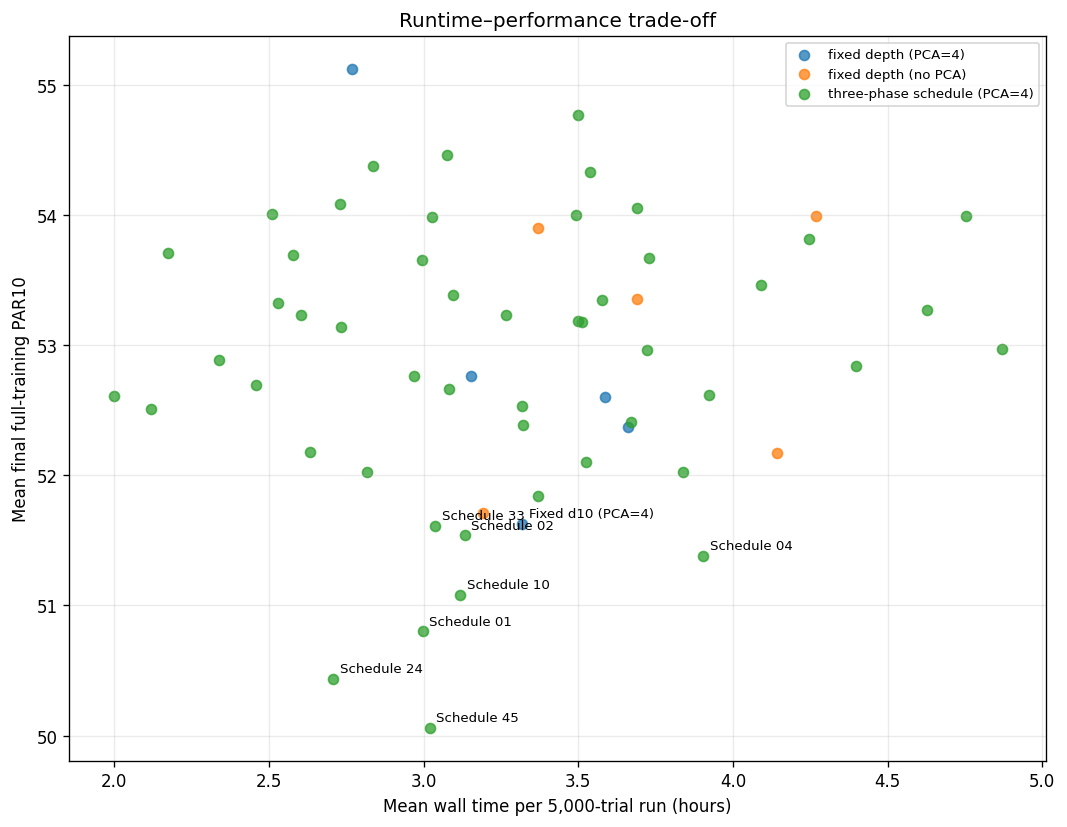

In [11]:
plot_runtime_performance(data)
plt.show()

## Automatically calculated findings

These statements summarize the current cached results and update
automatically if the experiment data are replaced.

In [12]:
display(Markdown(findings_markdown(data)))

- **Best mean final policy:** Schedule 45 with PAR10 50.06 ± 1.698.
- **Best worst-seed robustness:** Schedule 24; its worst seed rank is 8.
- **Schedules versus the best fixed PCA=4 depth:** 1 schedules win on all three seeds and 4 win on at least two seeds.
- **Early/final Spearman correlation among schedules:** 0.175. Values near one mean early ranking is strongly predictive; values near zero favor adaptive decisions.
- **Runtime/final Spearman correlation among schedules:** 0.070. A negative value means slower schedules tended to finish better.
- The no-PCA fixed controls from `03_fixed_deterministic` are included as requested, but schedule-versus-fixed conclusions should primarily use the PCA=4 fixed controls because all three-phase schedules use PCA=4.